In [1]:
# Police Fatalities in the United States
# Data Visualization and Analysis

print("Visualization notebook started successfully.")

Visualization notebook started successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv(
    "../data/raw/Deaths_by_Police_US.csv",
    encoding="latin1"
)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully.
Rows: 2535
Columns: 14


In [5]:
df.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [6]:
print(df.columns.tolist())

['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


In [7]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    dayfirst=True
)

print(df["date"].dtype)

datetime64[ns]


In [8]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_of_week"] = df["date"].dt.day_name()

df[["date", "year", "month", "month_name", "day_of_week"]].head(10)

,date,year,month,month_name,day_of_week
0,2015-01-02,2015,1,January,Friday
1,2015-01-02,2015,1,January,Friday
2,2015-01-03,2015,1,January,Saturday
3,2015-01-04,2015,1,January,Sunday
4,2015-01-04,2015,1,January,Sunday
5,2015-01-04,2015,1,January,Sunday
6,2015-01-05,2015,1,January,Monday
7,2015-01-06,2015,1,January,Tuesday
8,2015-01-06,2015,1,January,Tuesday
9,2015-01-06,2015,1,January,Tuesday


In [9]:
yearly_counts = (
    df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

yearly_counts.columns = ["year", "fatalities"]

yearly_counts

,year,fatalities
0,2015,991
1,2016,963
2,2017,581


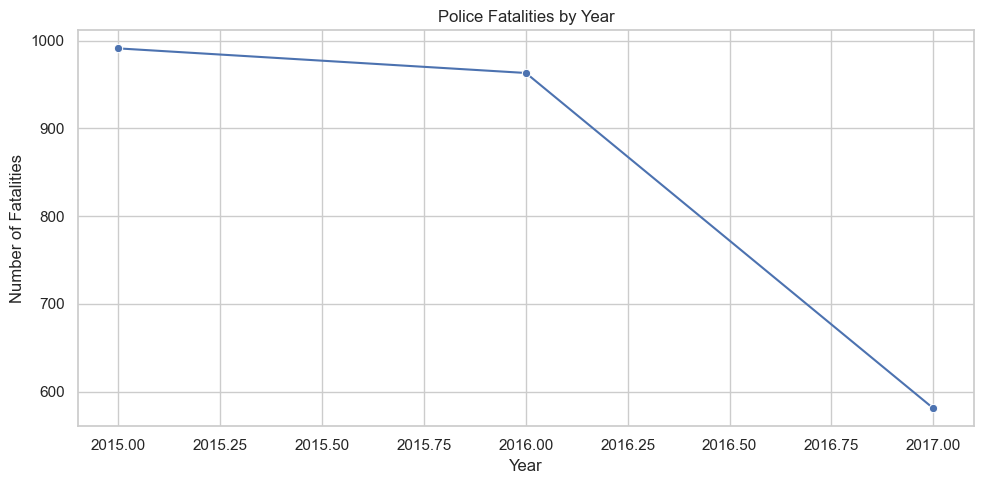

In [10]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_counts,
    x="year",
    y="fatalities",
    marker="o"
)

plt.title("Police Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [11]:
monthly_counts = (
    df.groupby(["year", "month"])
    .size()
    .reset_index(name="fatalities")
)

monthly_counts["date"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" +
    monthly_counts["month"].astype(str) + "-01"
)

monthly_counts = monthly_counts.sort_values("date")

monthly_counts.head()

,year,month,fatalities,date
0,2015,1,76,2015-01-01
1,2015,2,77,2015-02-01
2,2015,3,92,2015-03-01
3,2015,4,84,2015-04-01
4,2015,5,71,2015-05-01


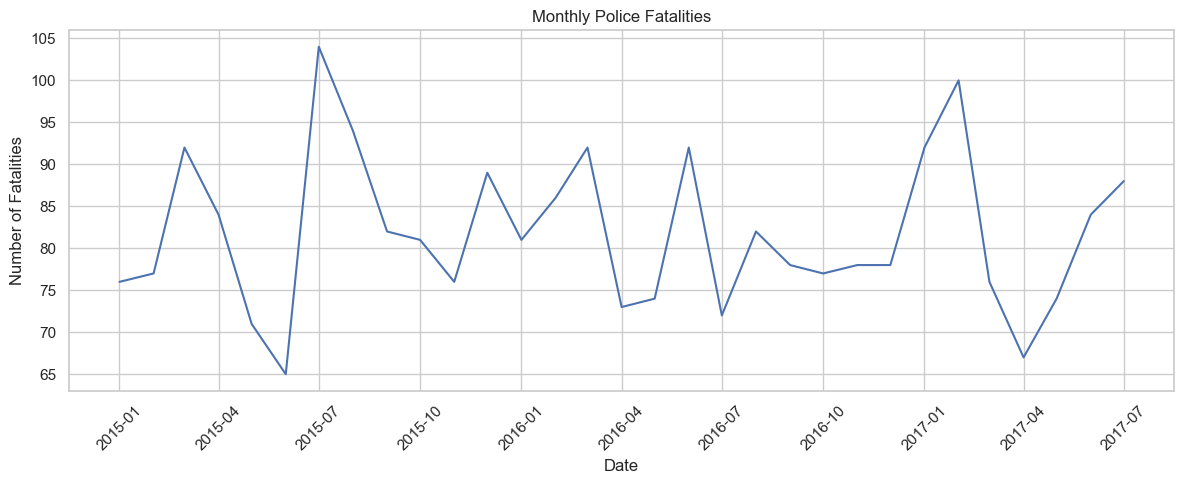

In [12]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_counts,
    x="date",
    y="fatalities"
)

plt.title("Monthly Police Fatalities")
plt.xlabel("Date")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 17, 25, 35, 45, 55, 65, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

age_group_counts = (
    df["age_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_counts.columns = ["age_group", "fatalities"]

age_group_counts

,age_group,fatalities
0,<18,51
1,18-25,502
2,26-35,760
3,36-45,546
4,46-55,364
5,56-65,175
6,66+,60


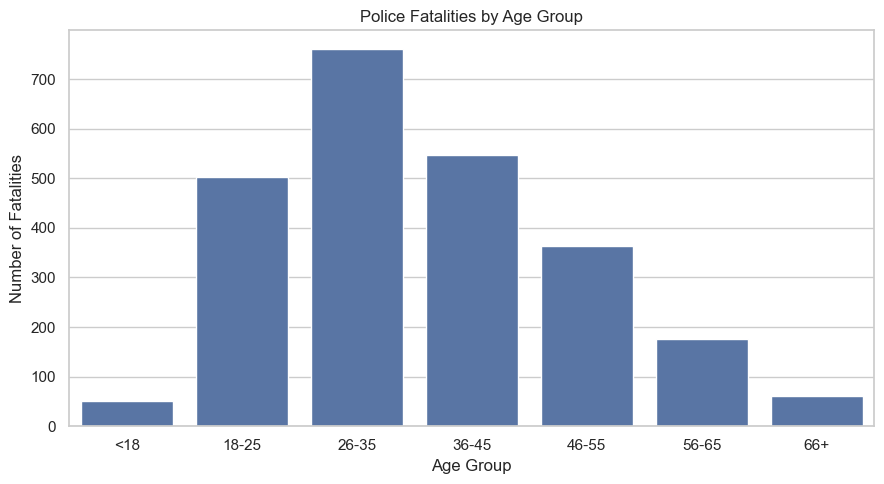

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_counts,
    x="age_group",
    y="fatalities"
)

plt.title("Police Fatalities by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [15]:
gender_counts = (
    df["gender"]
    .value_counts()
    .dropna()
    .reset_index()
)

gender_counts.columns = ["gender", "fatalities"]

gender_counts

,gender,fatalities
0,M,2428
1,F,107


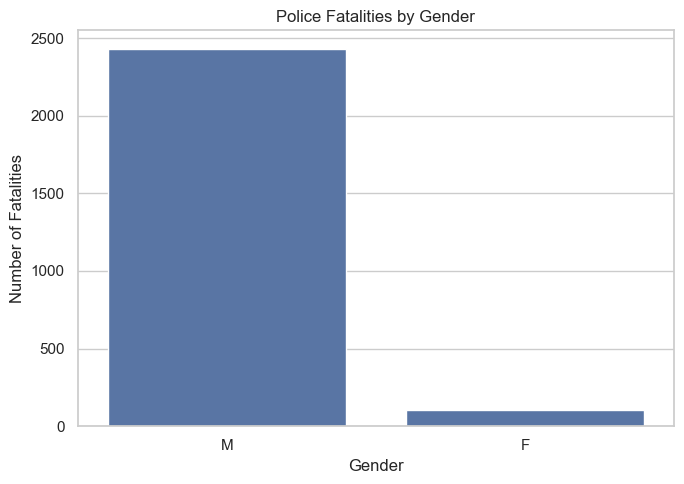

In [16]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_counts,
    x="gender",
    y="fatalities"
)

plt.title("Police Fatalities by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [17]:
race_counts = (
    df["race"]
    .value_counts(dropna=False)
    .reset_index()
)

race_counts.columns = ["race", "fatalities"]

race_counts

,race,fatalities
0,W,1201
1,B,618
2,H,423
3,NaN,195
4,A,39
5,N,31
6,O,28


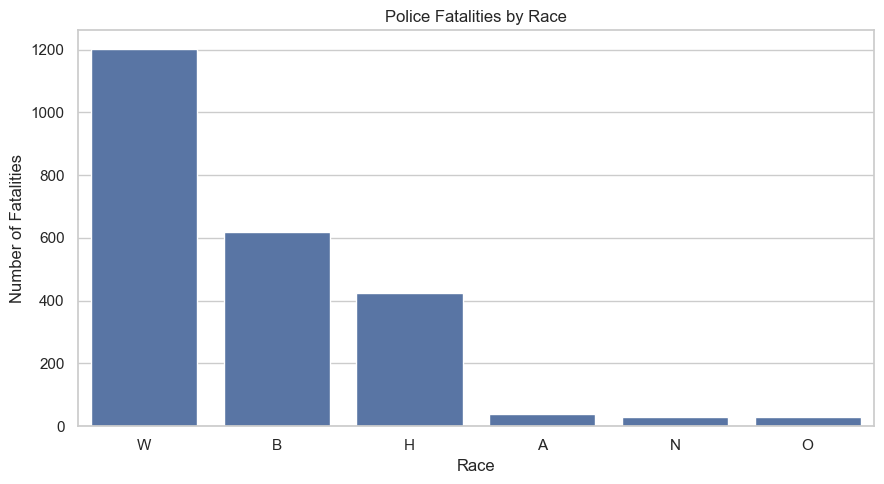

In [18]:
race_chart = race_counts.dropna(subset=["race"])

plt.figure(figsize=(9, 5))

sns.barplot(
    data=race_chart,
    x="race",
    y="fatalities"
)

plt.title("Police Fatalities by Race")
plt.xlabel("Race")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [19]:
threat_counts = (
    df["threat_level"]
    .value_counts(dropna=False)
    .reset_index()
)

threat_counts.columns = ["threat_level", "fatalities"]

threat_counts

,threat_level,fatalities
0,attack,1611
1,other,766
2,undetermined,158


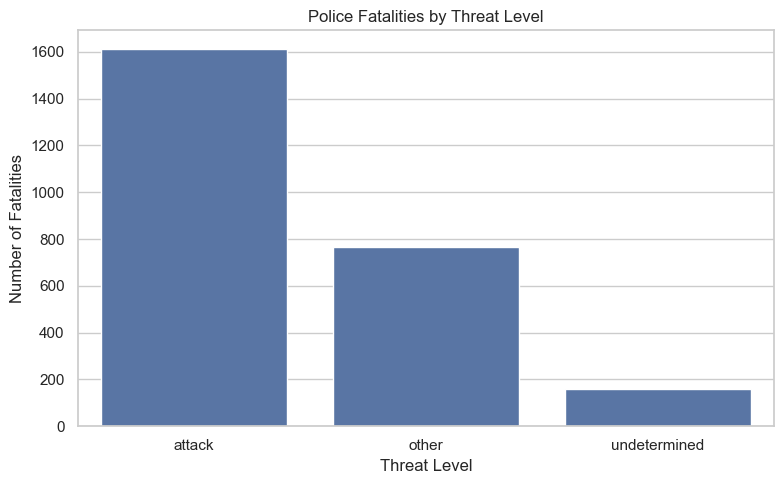

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=threat_counts,
    x="threat_level",
    y="fatalities"
)

plt.title("Police Fatalities by Threat Level")
plt.xlabel("Threat Level")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [21]:
flee_counts = (
    df["flee"]
    .value_counts(dropna=False)
    .reset_index()
)

flee_counts.columns = ["flee", "fatalities"]

flee_counts

,flee,fatalities
0,Not fleeing,1695
1,Car,385
2,Foot,294
3,Other,96
4,NaN,65


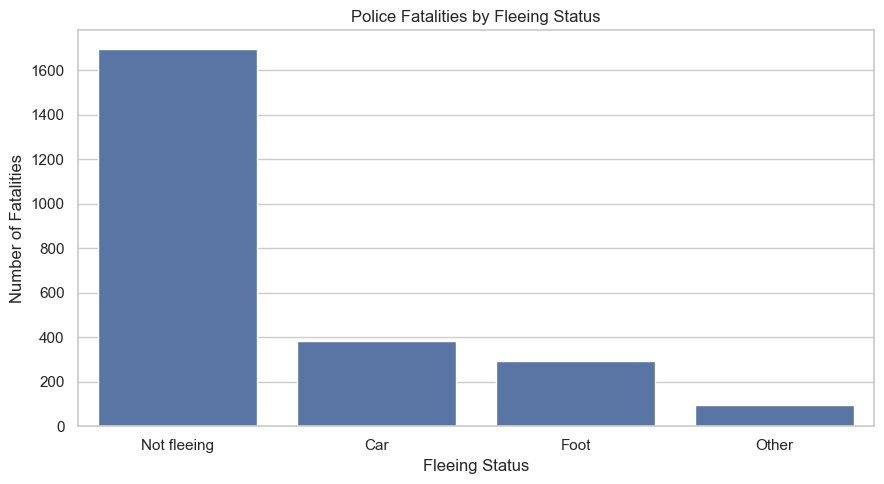

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=flee_counts,
    x="flee",
    y="fatalities"
)

plt.title("Police Fatalities by Fleeing Status")
plt.xlabel("Fleeing Status")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [23]:
armed_counts = (
    df["armed"]
    .value_counts(dropna=False)
    .head(10)
    .reset_index()
)

armed_counts.columns = ["armed", "fatalities"]

armed_counts

,armed,fatalities
0,gun,1398
1,knife,373
2,vehicle,177
3,unarmed,171
4,undetermined,117
5,toy weapon,104
6,machete,18
7,unknown weapon,18
8,Taser,9
9,ax,9


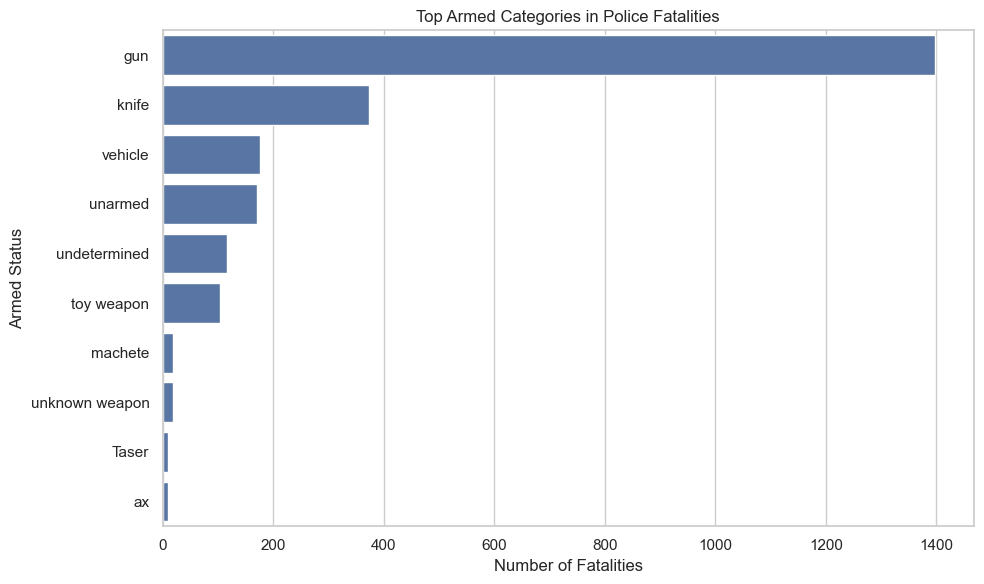

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=armed_counts,
    x="fatalities",
    y="armed"
)

plt.title("Top Armed Categories in Police Fatalities")
plt.xlabel("Number of Fatalities")
plt.ylabel("Armed Status")

plt.tight_layout()
plt.show()

In [25]:
manner_counts = (
    df["manner_of_death"]
    .value_counts(dropna=False)
    .reset_index()
)

manner_counts.columns = ["manner_of_death", "fatalities"]

manner_counts

,manner_of_death,fatalities
0,shot,2363
1,shot and Tasered,172


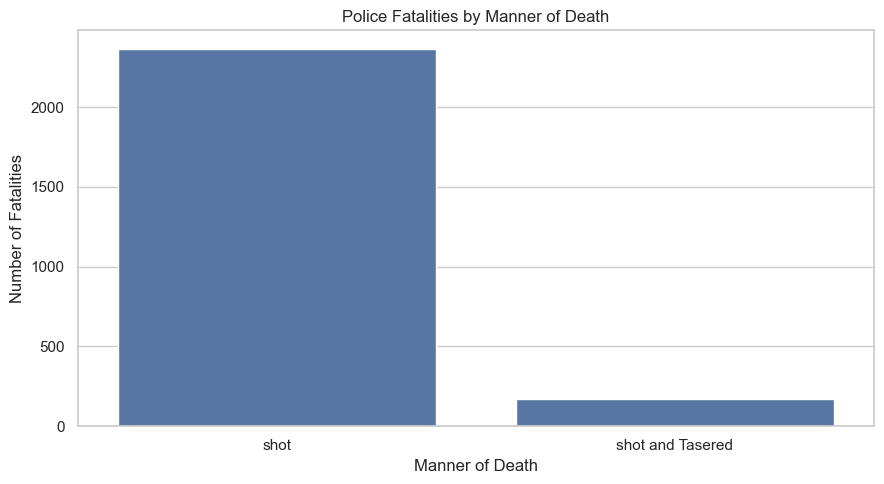

In [26]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=manner_counts,
    x="manner_of_death",
    y="fatalities"
)

plt.title("Police Fatalities by Manner of Death")
plt.xlabel("Manner of Death")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [27]:
mental_counts = (
    df["signs_of_mental_illness"]
    .value_counts(dropna=False)
    .reset_index()
)

mental_counts.columns = ["signs_of_mental_illness", "fatalities"]

mental_counts

,signs_of_mental_illness,fatalities
0,False,1902
1,True,633


In [28]:
mental_counts = (
    df["signs_of_mental_illness"]
    .value_counts(dropna=False)
    .reset_index()
)

mental_counts.columns = ["signs_of_mental_illness", "fatalities"]

mental_counts

,signs_of_mental_illness,fatalities
0,False,1902
1,True,633


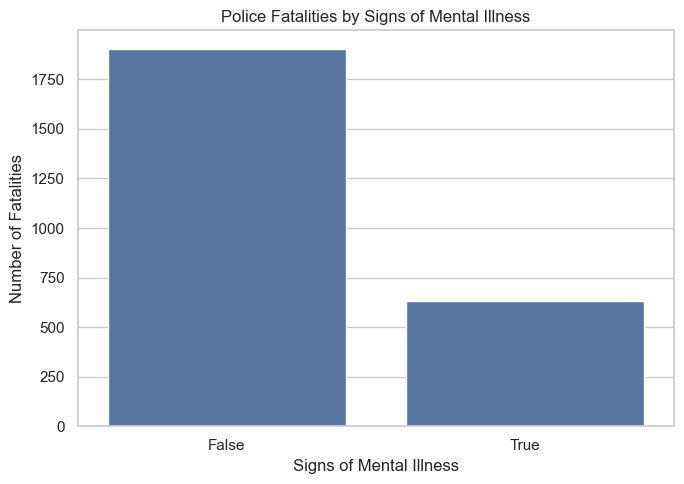

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=mental_counts,
    x="signs_of_mental_illness",
    y="fatalities"
)

plt.title("Police Fatalities by Signs of Mental Illness")
plt.xlabel("Signs of Mental Illness")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [30]:
camera_counts = (
    df["body_camera"]
    .value_counts(dropna=False)
    .reset_index()
)

camera_counts.columns = ["body_camera", "fatalities"]

camera_counts

,body_camera,fatalities
0,False,2264
1,True,271


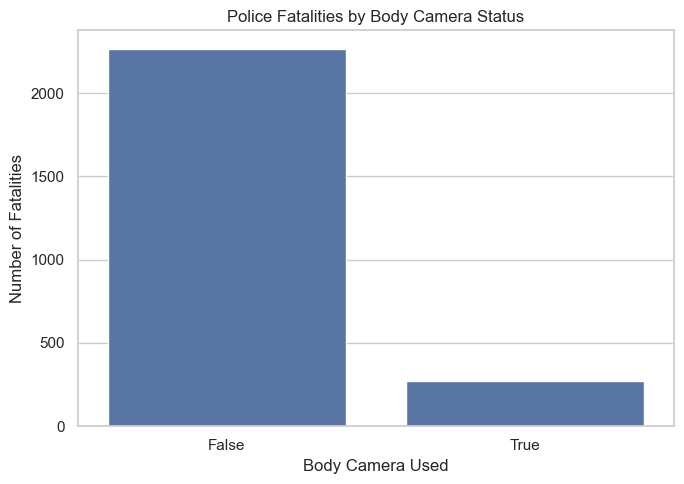

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=camera_counts,
    x="body_camera",
    y="fatalities"
)

plt.title("Police Fatalities by Body Camera Status")
plt.xlabel("Body Camera Used")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [32]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 17, 25, 35, 45, 55, 65, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

age_group_counts = (
    df["age_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_counts.columns = ["age_group", "fatalities"]

age_group_counts

,age_group,fatalities
0,<18,51
1,18-25,502
2,26-35,760
3,36-45,546
4,46-55,364
5,56-65,175
6,66+,60


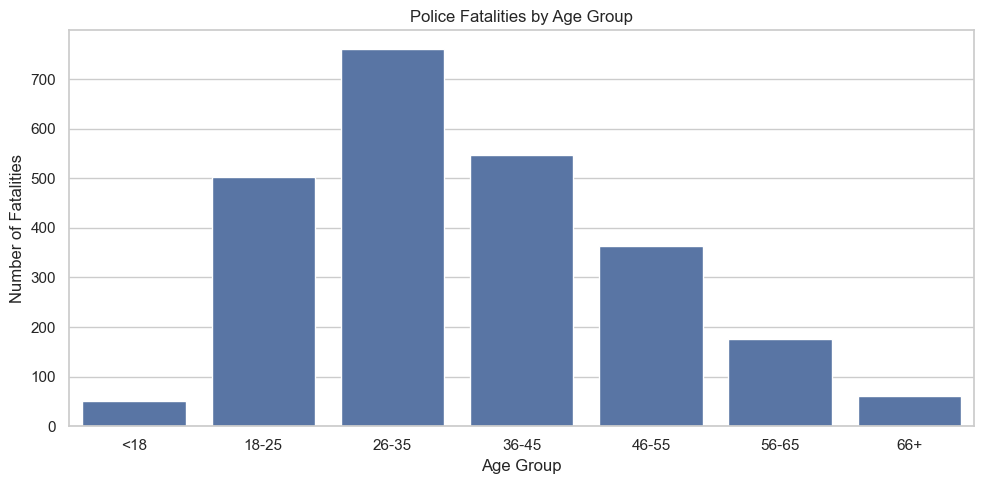

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_group_counts,
    x="age_group",
    y="fatalities"
)

plt.title("Police Fatalities by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [34]:
state_counts = (
    df["state"]
    .value_counts()
    .head(15)
    .reset_index()
)

state_counts.columns = ["state", "fatalities"]

state_counts

,state,fatalities
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


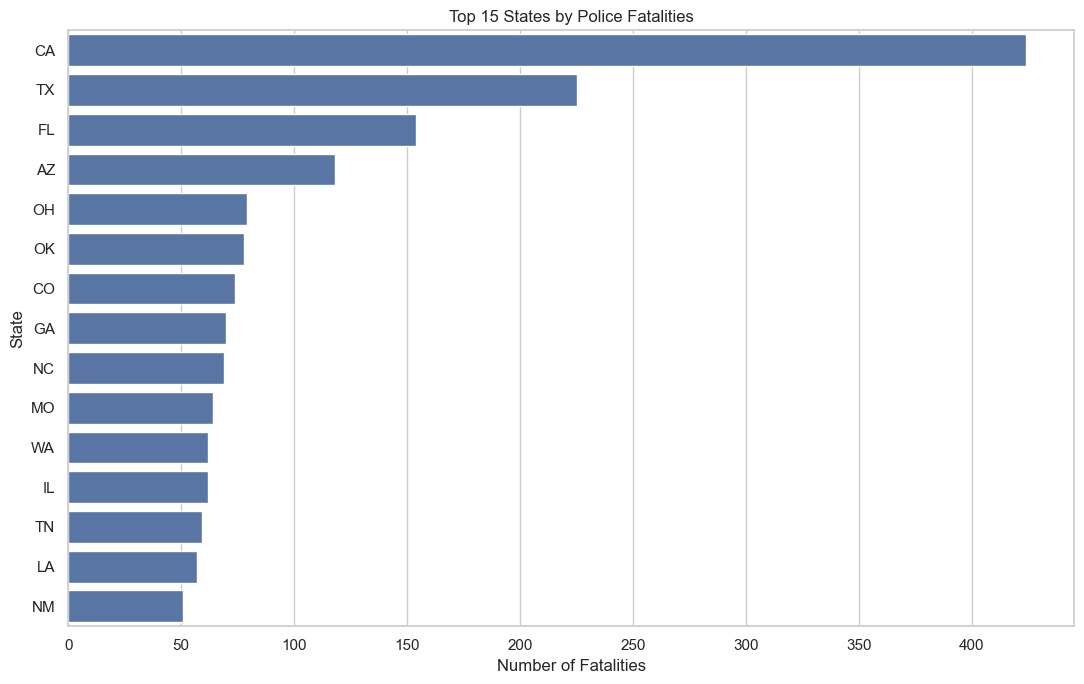

In [35]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=state_counts,
    x="fatalities",
    y="state"
)

plt.title("Top 15 States by Police Fatalities")
plt.xlabel("Number of Fatalities")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [36]:
city_counts = (
    df["city"]
    .value_counts()
    .head(15)
    .reset_index()
)

city_counts.columns = ["city", "fatalities"]

city_counts

,city,fatalities
0,Los Angeles,39
1,Phoenix,31
2,Houston,27
3,Chicago,25
4,Las Vegas,21
5,San Antonio,20
6,Columbus,19
7,Miami,18
8,Austin,18
9,St. Louis,15


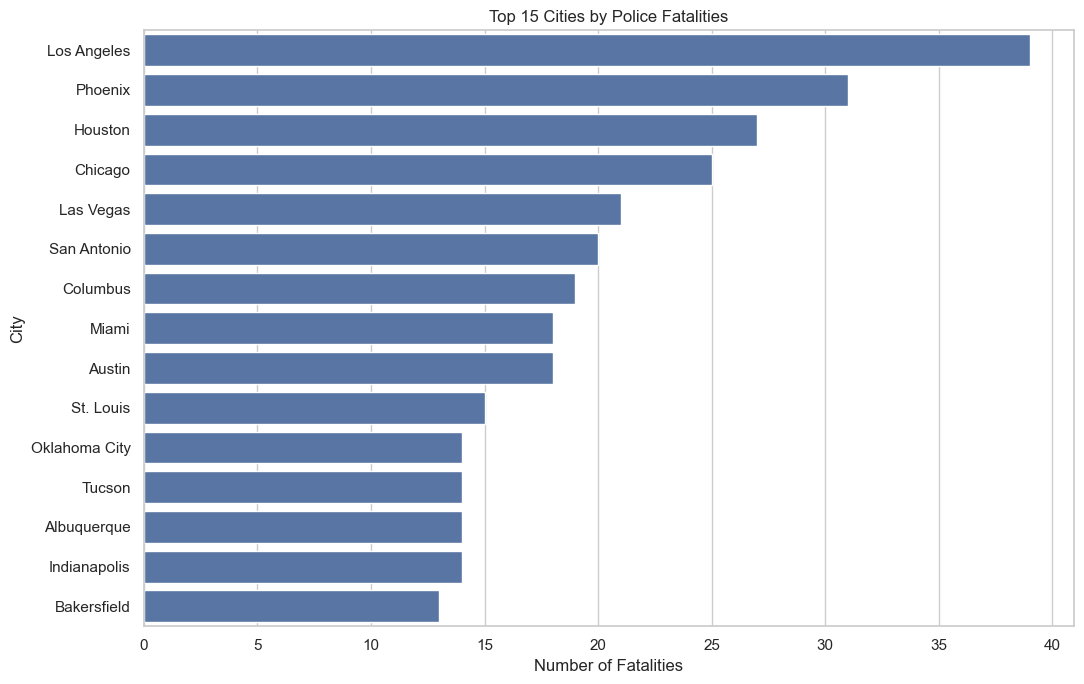

In [37]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=city_counts,
    x="fatalities",
    y="city"
)

plt.title("Top 15 Cities by Police Fatalities")
plt.xlabel("Number of Fatalities")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [38]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_of_week"] = df["date"].dt.day_name()

df[["date", "year", "month", "month_name", "day_of_week"]].head()

,date,year,month,month_name,day_of_week
0,2015-01-02,2015,1,January,Friday
1,2015-01-02,2015,1,January,Friday
2,2015-01-03,2015,1,January,Saturday
3,2015-01-04,2015,1,January,Sunday
4,2015-01-04,2015,1,January,Sunday


In [39]:
yearly_counts = (
    df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

yearly_counts.columns = ["year", "fatalities"]

yearly_counts

,year,fatalities
0,2015,991
1,2016,963
2,2017,581


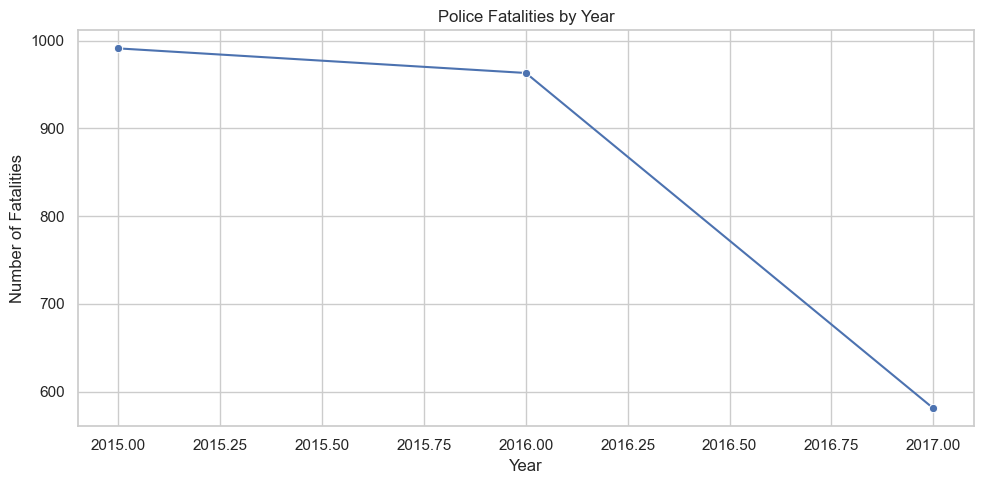

In [40]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_counts,
    x="year",
    y="fatalities",
    marker="o"
)

plt.title("Police Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [41]:
monthly_counts = (
    df["month"]
    .value_counts()
    .sort_index()
    .reset_index()
)

monthly_counts.columns = ["month", "fatalities"]

monthly_counts

,month,fatalities
0,1,249
1,2,263
2,3,260
3,4,224
4,5,219
5,6,241
6,7,264
7,8,176
8,9,160
9,10,158


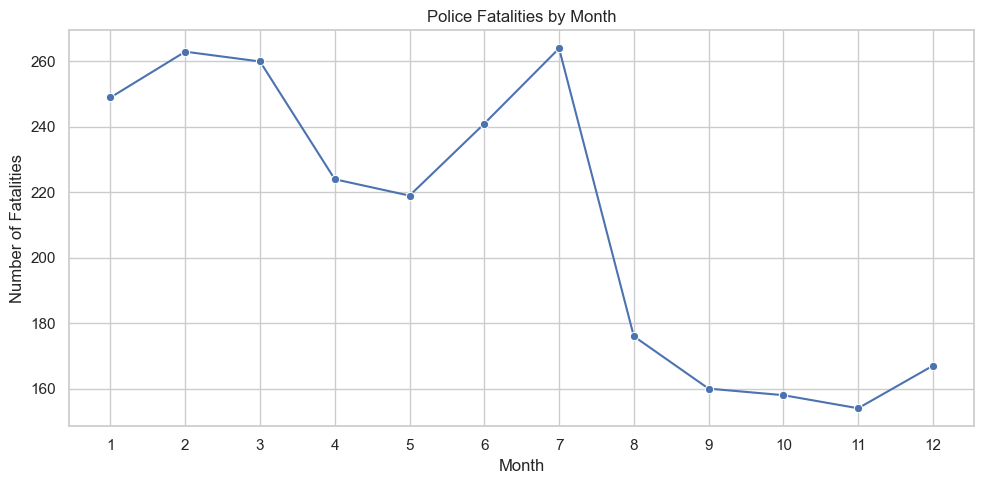

In [42]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_counts,
    x="month",
    y="fatalities",
    marker="o"
)

plt.title("Police Fatalities by Month")
plt.xlabel("Month")
plt.ylabel("Number of Fatalities")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [43]:
weekday_counts = (
    df["day_of_week"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_counts.columns = ["day_of_week", "fatalities"]

weekday_counts

,day_of_week,fatalities
0,Monday,324
1,Tuesday,389
2,Wednesday,396
3,Thursday,372
4,Friday,351
5,Saturday,347
6,Sunday,356


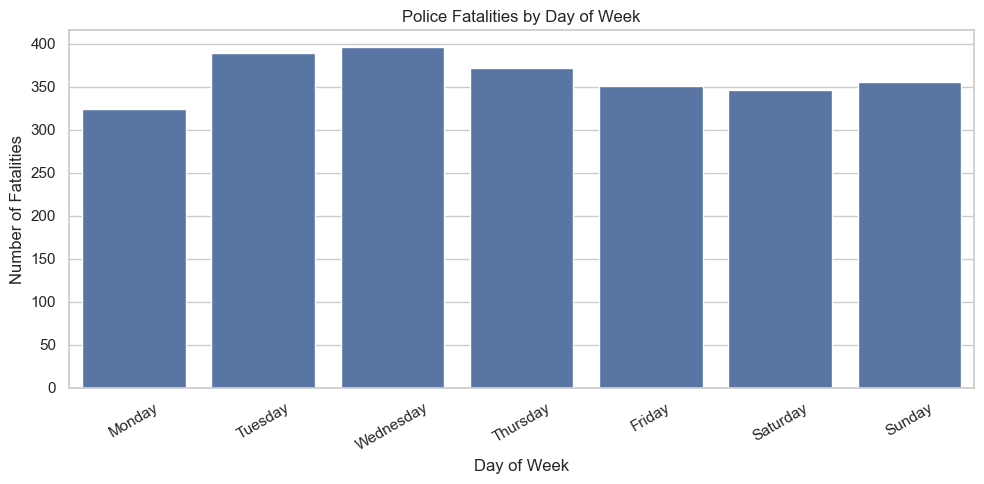

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_counts,
    x="day_of_week",
    y="fatalities"
)

plt.title("Police Fatalities by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [45]:
gender_age = pd.crosstab(
    df["age_group"],
    df["gender"]
)

gender_age

gender,F,M
age_group,,
<18,6,45
18-25,19,483
26-35,26,734
36-45,26,520
46-55,19,345
56-65,6,169
66+,2,58


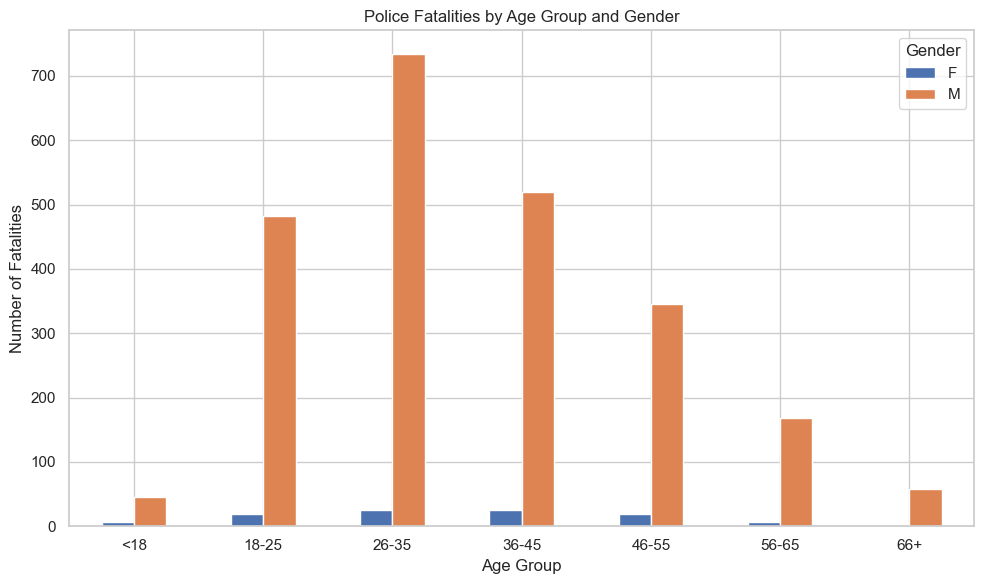

In [46]:
gender_age.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Police Fatalities by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [47]:
race_gender = pd.crosstab(
    df["race"],
    df["gender"]
)

race_gender

gender,F,M
race,,
A,1,38
B,26,592
H,5,418
N,5,26
O,2,26
W,59,1142


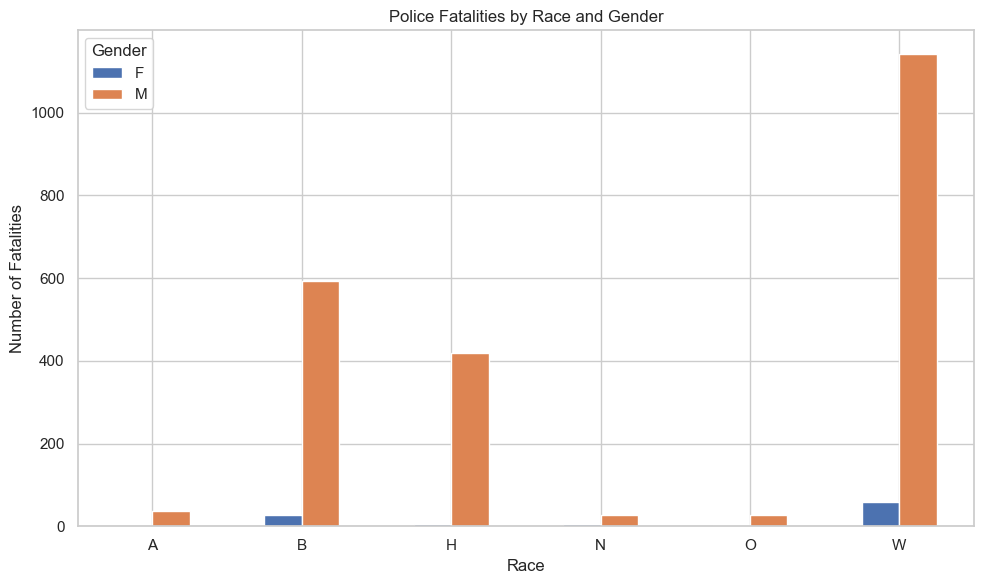

In [48]:
race_gender.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Police Fatalities by Race and Gender")
plt.xlabel("Race")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [49]:
threat_armed = pd.crosstab(
    df["threat_level"],
    df["armed"]
)

threat_armed

armed,Taser,air conditioner,ax,baseball bat,baseball bat and bottle,baseball bat and fireplace poker,baton,bayonet,bean-bag gun,beer bottle,...,spear,stapler,straight edge razor,sword,tire iron,toy weapon,unarmed,undetermined,unknown weapon,vehicle
threat_level,,,,,,,,,,,,,,,,,,,,,
attack,6,0,1,4,0,0,2,0,0,0,...,0,0,0,3,0,80,65,20,8,71
other,3,0,8,3,1,1,0,0,1,1,...,1,1,1,5,1,23,80,25,7,98
undetermined,0,1,0,1,0,0,0,1,0,1,...,0,0,0,0,0,1,26,72,3,8


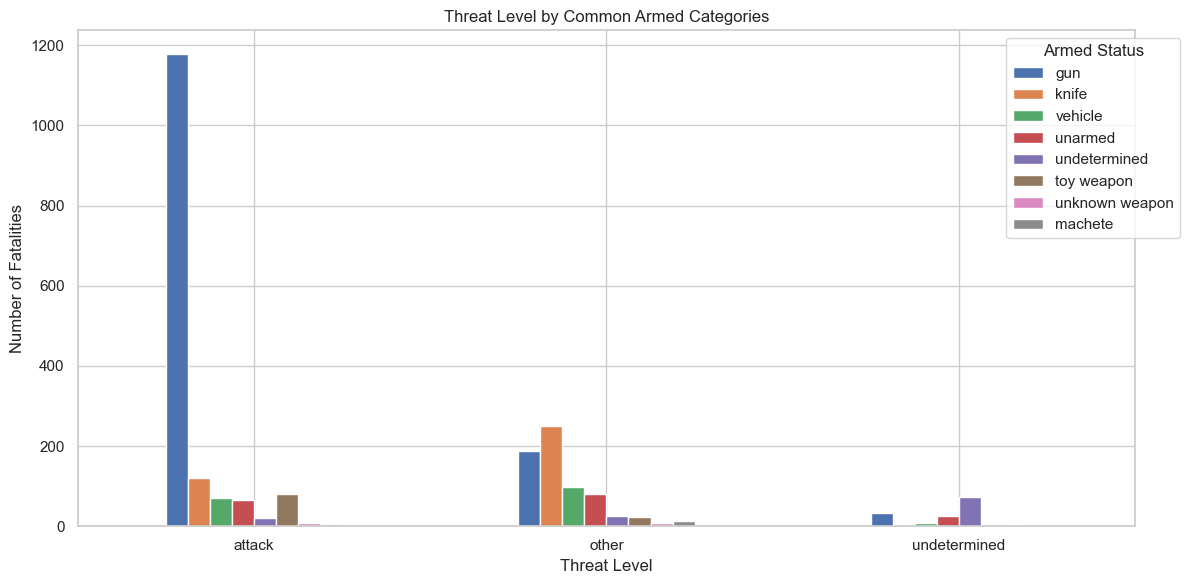

In [50]:
top_armed = (
    df["armed"]
    .value_counts()
    .head(8)
    .index
)

threat_armed_top = pd.crosstab(
    df["threat_level"],
    df["armed"]
)[top_armed]

threat_armed_top.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Threat Level by Common Armed Categories")
plt.xlabel("Threat Level")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=0)
plt.legend(title="Armed Status", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [51]:
mental_threat = pd.crosstab(
    df["signs_of_mental_illness"],
    df["threat_level"]
)

mental_threat

threat_level,attack,other,undetermined
signs_of_mental_illness,,,
False,1227,533,142
True,384,233,16


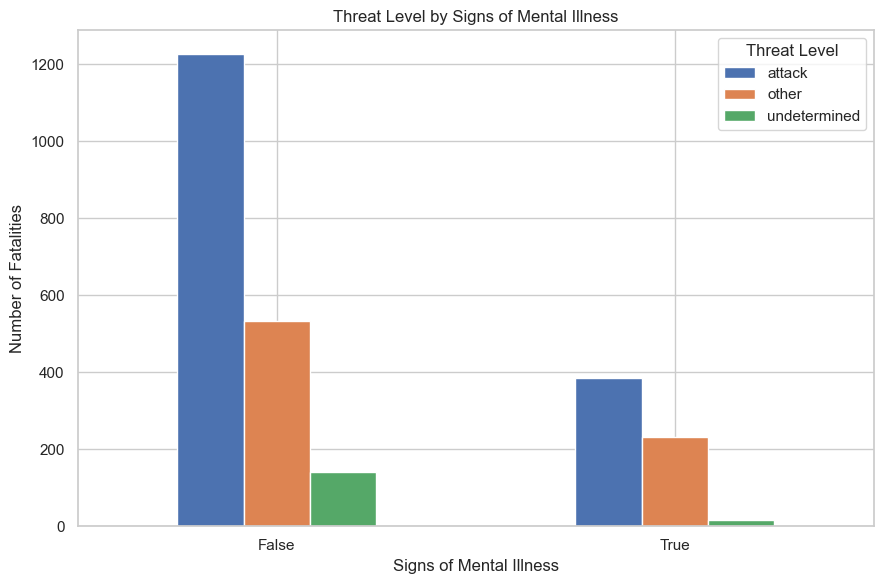

In [52]:
mental_threat.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Threat Level by Signs of Mental Illness")
plt.xlabel("Signs of Mental Illness")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=0)
plt.legend(title="Threat Level")

plt.tight_layout()
plt.show()

In [53]:
camera_threat = pd.crosstab(
    df["body_camera"],
    df["threat_level"]
)

camera_threat

threat_level,attack,other,undetermined
body_camera,,,
False,1462,660,142
True,149,106,16


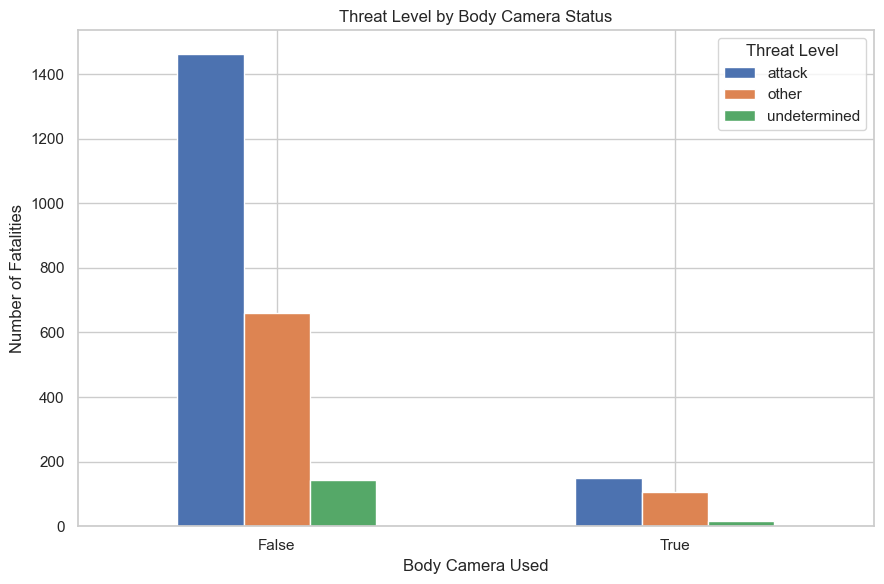

In [54]:
camera_threat.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Threat Level by Body Camera Status")
plt.xlabel("Body Camera Used")
plt.ylabel("Number of Fatalities")

plt.xticks(rotation=0)
plt.legend(title="Threat Level")

plt.tight_layout()
plt.show()

In [55]:
total_fatalities = len(df)

average_age = df["age"].mean()

median_age = df["age"].median()

male_fatalities = (df["gender"] == "M").sum()

female_fatalities = (df["gender"] == "F").sum()

mental_illness_yes = (df["signs_of_mental_illness"] == True).sum()

body_camera_yes = (df["body_camera"] == True).sum()

print("Total fatalities:", total_fatalities)
print("Average age:", round(average_age, 2))
print("Median age:", median_age)
print("Male fatalities:", male_fatalities)
print("Female fatalities:", female_fatalities)
print("Signs of mental illness:", mental_illness_yes)
print("Body camera used:", body_camera_yes)

Total fatalities: 2535
Average age: 36.61
Median age: 34.0
Male fatalities: 2428
Female fatalities: 107
Signs of mental illness: 633
Body camera used: 271


In [56]:
gender_percent = (
    df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

gender_percent.columns = ["gender", "percentage"]

gender_percent

,gender,percentage
0,M,95.78
1,F,4.22


In [57]:
age_percent = (
    df["age_group"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

age_percent.columns = ["age_group", "percentage"]

age_percent

,age_group,percentage
0,<18,2.07
1,18-25,20.42
2,26-35,30.92
3,36-45,22.21
4,46-55,14.81
5,56-65,7.12
6,66+,2.44


In [58]:
race_percent = (
    df["race"]
    .value_counts(normalize=True)
    .dropna()
    .mul(100)
    .round(2)
    .reset_index()
)

race_percent.columns = ["race", "percentage"]

race_percent

,race,percentage
0,W,51.32
1,B,26.41
2,H,18.08
3,A,1.67
4,N,1.32
5,O,1.20


In [59]:
threat_percent = (
    df["threat_level"]
    .value_counts(normalize=True)
    .dropna()
    .mul(100)
    .round(2)
    .reset_index()
)

threat_percent.columns = ["threat_level", "percentage"]

threat_percent

,threat_level,percentage
0,attack,63.55
1,other,30.22
2,undetermined,6.23


In [60]:
df["armed_status"] = df["armed"].apply(
    lambda x: "Unknown" if pd.isna(x)
    else "Unarmed/Unknown" if str(x).lower() in [
        "unarmed",
        "unknown",
        "undetermined"
    ]
    else "Armed"
)

armed_status_counts = (
    df["armed_status"]
    .value_counts()
    .reset_index()
)

armed_status_counts.columns = ["armed_status", "fatalities"]

armed_status_counts

,armed_status,fatalities
0,Armed,2238
1,Unarmed/Unknown,288
2,Unknown,9


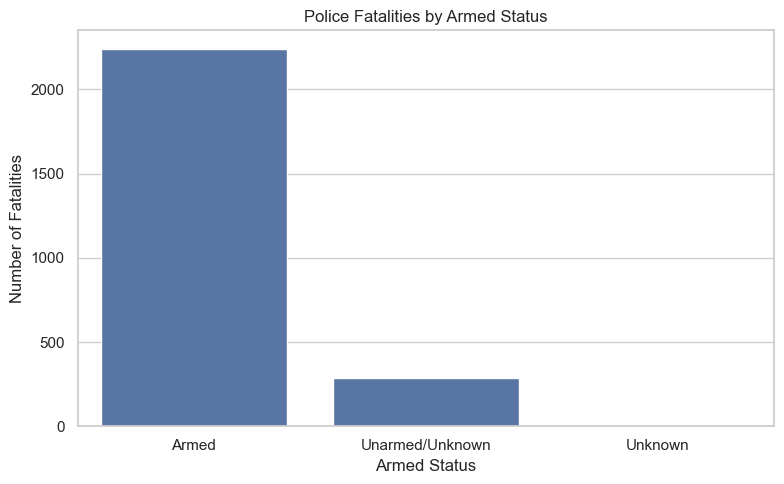

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=armed_status_counts,
    x="armed_status",
    y="fatalities"
)

plt.title("Police Fatalities by Armed Status")
plt.xlabel("Armed Status")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

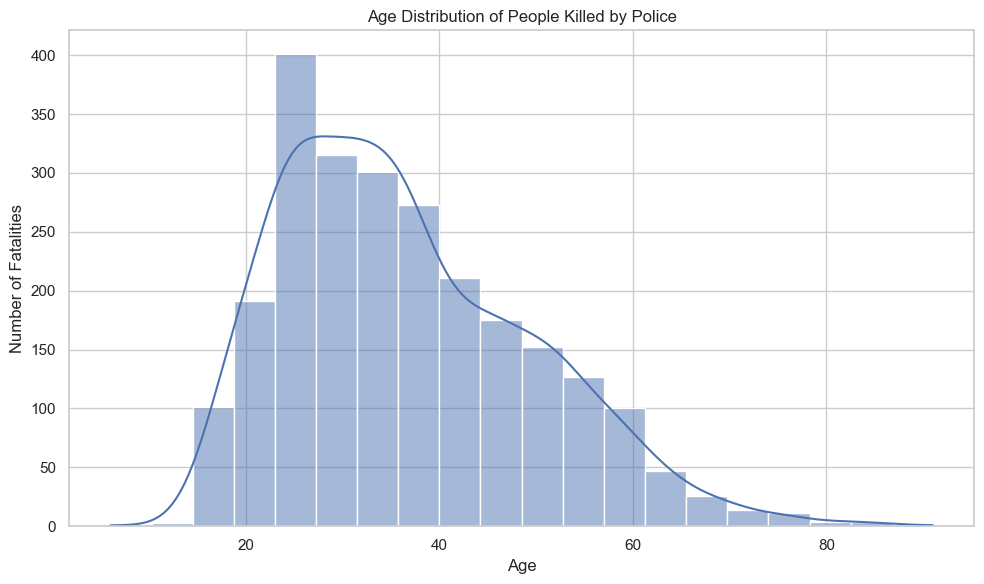

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of People Killed by Police")
plt.xlabel("Age")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

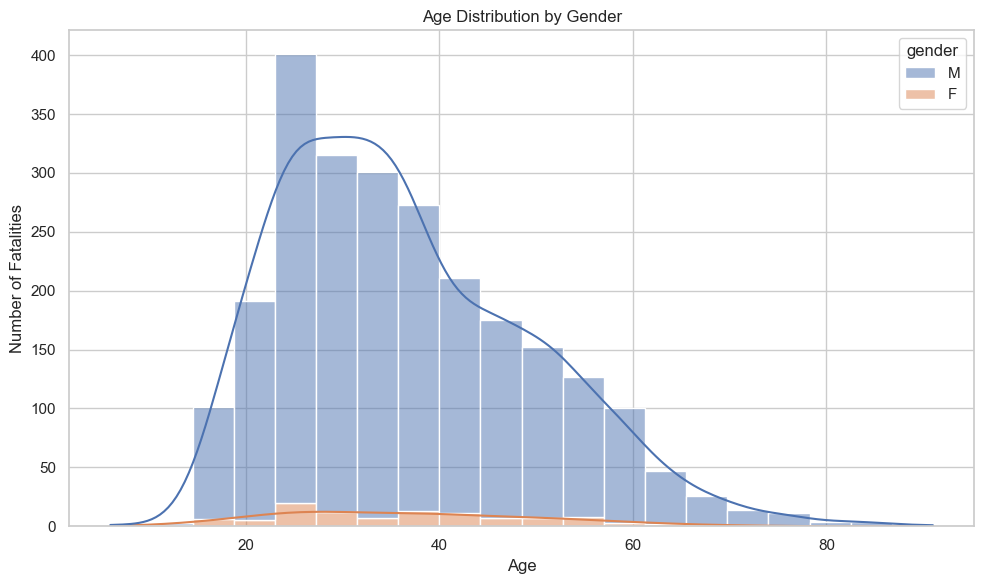

In [63]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    hue="gender",
    bins=20,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [64]:
year_gender = pd.crosstab(
    df["year"],
    df["gender"]
)

year_gender

gender,F,M
year,,
2015,42,949
2016,40,923
2017,25,556


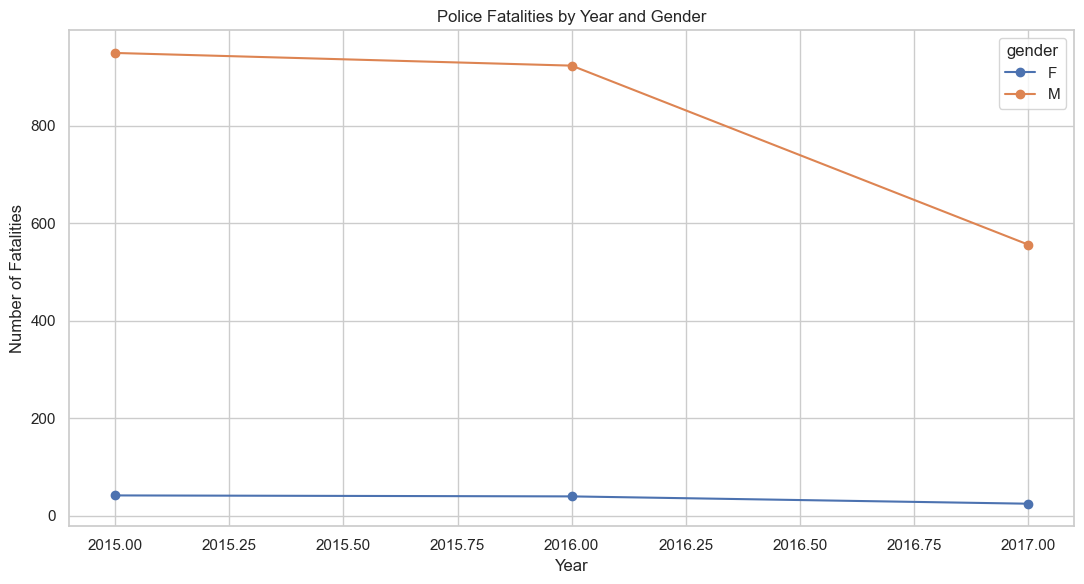

In [65]:
year_gender.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

plt.title("Police Fatalities by Year and Gender")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [66]:
year_age = pd.crosstab(
    df["year"],
    df["age_group"]
)

year_age

age_group,<18,18-25,26-35,36-45,46-55,56-65,66+
year,,,,,,,
2015,18,197,315,202,152,73,23
2016,16,189,283,233,131,63,22
2017,17,116,162,111,81,39,15


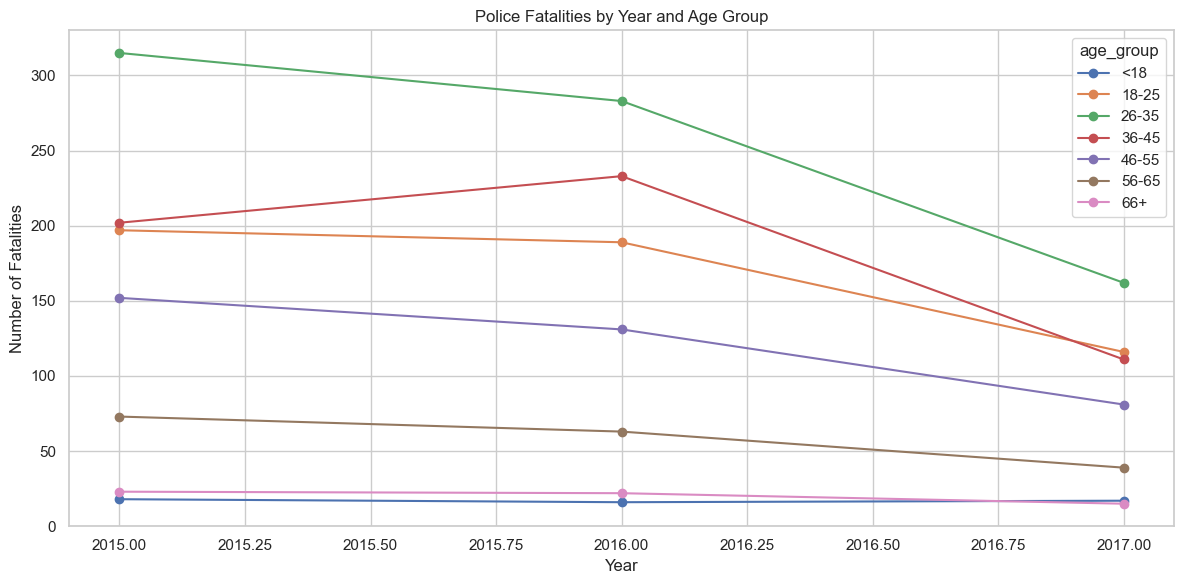

In [67]:
year_age.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Police Fatalities by Year and Age Group")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [68]:
year_threat = pd.crosstab(
    df["year"],
    df["threat_level"]
)

year_threat

threat_level,attack,other,undetermined
year,,,
2015,730,217,44
2016,539,355,69
2017,342,194,45


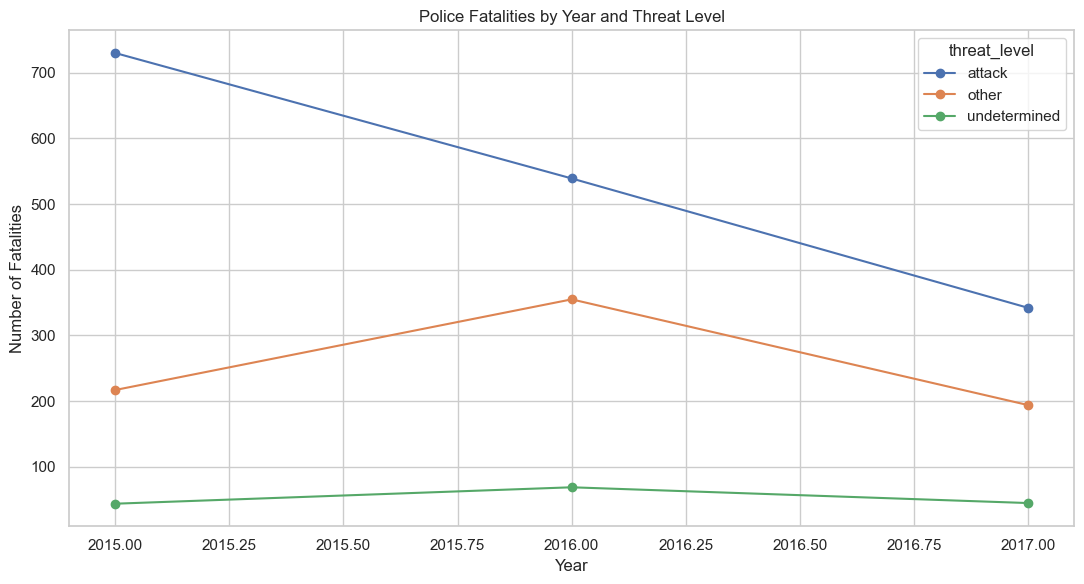

In [69]:
year_threat.plot(
    kind="line",
    marker="o",
    figsize=(11, 6)
)

plt.title("Police Fatalities by Year and Threat Level")
plt.xlabel("Year")
plt.ylabel("Number of Fatalities")

plt.tight_layout()
plt.show()

In [70]:
summary_stats = pd.DataFrame({
    "Metric": [
        "Total Fatalities",
        "Average Age",
        "Median Age",
        "Male Fatalities",
        "Female Fatalities",
        "Mental Illness Indicator",
        "Body Camera Used"
    ],
    "Value": [
        total_fatalities,
        round(average_age, 2),
        median_age,
        male_fatalities,
        female_fatalities,
        mental_illness_yes,
        body_camera_yes
    ]
})

summary_stats

,Metric,Value
0,Total Fatalities,2535.00
1,Average Age,36.61
2,Median Age,34.00
3,Male Fatalities,2428.00
4,Female Fatalities,107.00
5,Mental Illness Indicator,633.00
6,Body Camera Used,271.00


In [71]:
summary_stats.to_csv(
    "../data/processed/summary_statistics.csv",
    index=False
)

In [72]:
gender_percent.to_csv(
    "../data/processed/gender_percentages.csv",
    index=False
)

age_percent.to_csv(
    "../data/processed/age_percentages.csv",
    index=False
)

race_percent.to_csv(
    "../data/processed/race_percentages.csv",
    index=False
)

threat_percent.to_csv(
    "../data/processed/threat_percentages.csv",
    index=False
)

In [73]:
dashboard_df = df.copy()

dashboard_df.shape

(2535, 20)

In [74]:
dashboard_df = dashboard_df[
    [
        "date",
        "year",
        "month",
        "age",
        "age_group",
        "gender",
        "race",
        "threat_level",
        "flee",
        "armed",
        "armed_status",
        "manner_of_death",
        "signs_of_mental_illness",
        "body_camera",
        "state",
        "city"
    ]
].copy()

dashboard_df.head()

,date,year,month,age,age_group,gender,race,threat_level,flee,armed,armed_status,manner_of_death,signs_of_mental_illness,body_camera,state,city
0,2015-01-02,2015,1,53.0,46-55,M,A,attack,Not fleeing,gun,Armed,shot,True,False,WA,Shelton
1,2015-01-02,2015,1,47.0,46-55,M,W,attack,Not fleeing,gun,Armed,shot,False,False,OR,Aloha
2,2015-01-03,2015,1,23.0,18-25,M,H,other,Not fleeing,unarmed,Unarmed/Unknown,shot and Tasered,False,False,KS,Wichita
3,2015-01-04,2015,1,32.0,26-35,M,W,attack,Not fleeing,toy weapon,Armed,shot,True,False,CA,San Francisco
4,2015-01-04,2015,1,39.0,36-45,M,H,attack,Not fleeing,nail gun,Armed,shot,False,False,CO,Evans


In [75]:
dashboard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2535 non-null   datetime64[ns]
 1   year                     2535 non-null   int32         
 2   month                    2535 non-null   int32         
 3   age                      2458 non-null   float64       
 4   age_group                2458 non-null   category      
 5   gender                   2535 non-null   object        
 6   race                     2340 non-null   object        
 7   threat_level             2535 non-null   object        
 8   flee                     2470 non-null   object        
 9   armed                    2526 non-null   object        
 10  armed_status             2535 non-null   object        
 11  manner_of_death          2535 non-null   object        
 12  signs_of_mental_illness  2535 non-

In [76]:
dashboard_df.to_csv(
    "../data/processed/dashboard_data.csv",
    index=False
)

In [77]:
final_yearly = (
    dashboard_df
    .groupby("year")
    .size()
    .reset_index(name="fatalities")
)

final_yearly

,year,fatalities
0,2015,991
1,2016,963
2,2017,581


In [78]:
final_yearly.to_csv(
    "../data/processed/final_yearly_fatalities.csv",
    index=False
)

In [79]:
final_age = (
    dashboard_df
    .groupby("age_group", observed=True)
    .size()
    .reset_index(name="fatalities")
)

final_age

,age_group,fatalities
0,<18,51
1,18-25,502
2,26-35,760
3,36-45,546
4,46-55,364
5,56-65,175
6,66+,60


In [80]:
final_age.to_csv(
    "../data/processed/final_age_groups.csv",
    index=False
)

In [81]:
final_gender = (
    dashboard_df
    .groupby("gender")
    .size()
    .reset_index(name="fatalities")
)

final_gender

,gender,fatalities
0,F,107
1,M,2428


In [82]:
final_gender.to_csv(
    "../data/processed/final_gender.csv",
    index=False
)

In [83]:
final_race = (
    dashboard_df["race"]
    .value_counts()
    .dropna()
    .reset_index()
)

final_race.columns = ["race", "fatalities"]

final_race

,race,fatalities
0,W,1201
1,B,618
2,H,423
3,A,39
4,N,31
5,O,28


In [84]:
final_race.to_csv(
    "../data/processed/final_race.csv",
    index=False
)

In [85]:
final_threat = (
    dashboard_df["threat_level"]
    .value_counts()
    .dropna()
    .reset_index()
)

final_threat.columns = ["threat_level", "fatalities"]

final_threat

,threat_level,fatalities
0,attack,1611
1,other,766
2,undetermined,158


In [86]:
final_threat.to_csv(
    "../data/processed/final_threat_level.csv",
    index=False
)

In [87]:
final_state = (
    dashboard_df["state"]
    .value_counts()
    .head(15)
    .reset_index()
)

final_state.columns = ["state", "fatalities"]

final_state

,state,fatalities
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


In [88]:
final_state.to_csv(
    "../data/processed/final_states.csv",
    index=False
)

In [89]:
final_manner = (
    dashboard_df["manner_of_death"]
    .value_counts()
    .dropna()
    .reset_index()
)

final_manner.columns = ["manner_of_death", "fatalities"]

final_manner

,manner_of_death,fatalities
0,shot,2363
1,shot and Tasered,172


In [90]:
final_manner.to_csv(
    "../data/processed/final_manner_of_death.csv",
    index=False
)

In [91]:
final_monthly = (
    dashboard_df["month"]
    .value_counts()
    .sort_index()
    .reset_index()
)

final_monthly.columns = ["month", "fatalities"]

final_monthly

,month,fatalities
0,1,249
1,2,263
2,3,260
3,4,224
4,5,219
5,6,241
6,7,264
7,8,176
8,9,160
9,10,158


In [92]:
final_monthly.to_csv(
    "../data/processed/final_monthly_fatalities.csv",
    index=False
)